<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/QuestionNo8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Install Required Libraries

In [1]:
!pip install ultralytics roboflow opencv-python matplotlib pyyaml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.3 MB/s eta 0:00:00


In [8]:
!unzip NEUSurfaceDefectDataset.v1i.yolov8.zip

Archive:  NEUSurfaceDefectDataset.v1i.yolov8.zip
 extracting: README.dataset.txt      
 extracting: README.roboflow.txt     
 extracting: data.yaml               
   creating: train/
   creating: train/images/
 extracting: train/images/crazing_100_jpg.rf.80e4fd6411171e6223d9310c3925f271.jpg  
 extracting: train/images/crazing_101_jpg.rf.352873ff6b4e1212ab8e26c63311bbc6.jpg  
 extracting: train/images/crazing_102_jpg.rf.0776af296c182c2ab00d0098eb99548f.jpg  
 extracting: train/images/crazing_103_jpg.rf.e872d71ed409f424e674437e8ca83b23.jpg  
 extracting: train/images/crazing_104_jpg.rf.61b6a2e42f87ef18d010950d9135f443.jpg  
 extracting: train/images/crazing_105_jpg.rf.ee3a8fe1a7240aa4fb3aa06ce4d28394.jpg  
 extracting: train/images/crazing_106_jpg.rf.08bb0a4567bf66c56835f05505d11230.jpg  
 extracting: train/images/crazing_107_jpg.rf.534999e0a936af42dd3955d45509509f.jpg  
 extracting: train/images/crazing_108_jpg.rf.67c1e82008d636727ea34cdd3a4906e1.jpg  
 extracting: train/images/crazing_

Step 2: Import Libraries

In [9]:
import os
import cv2
import yaml
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

Step 3: Download Dataset from Roboflow


neu-surface-defect-dataset/

    train/
        images/
        labels/

    valid/
        images/
        labels/

    test/
        images/
        labels/

    data.yaml
    

Step 4: Verify Dataset Structure

Step 5: Read data.yaml

In [10]:
dataset_path = "/content/"

yaml_path = os.path.join(dataset_path,"data.yaml")

with open(yaml_path,'r') as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches'], 'roboflow': {'workspace': 'pavithraa-sekar', 'project': 'neu-surface-defect-dataset', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/pavithraa-sekar/neu-surface-defect-dataset/dataset/1'}}


Step 6: Display Dataset Classes

In [11]:

print("Classes:")

for i,name in enumerate(data['names']):
    print(i,name)

Classes:
0 crazing
1 inclusion
2 patches
3 pitted_surface
4 rolled-in_scale
5 scratches


Step 7: Function to Draw Bounding Boxes

In [12]:
def show_image(img_path,label_path):

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    h,w,_=img.shape

    with open(label_path) as f:

        labels=f.readlines()

    for line in labels:

        cls,x,y,bw,bh=map(float,line.split())

        x1=int((x-bw/2)*w)
        y1=int((y-bh/2)*h)
        x2=int((x+bw/2)*w)
        y2=int((y+bh/2)*h)

        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

        cv2.putText(img,
                    data['names'][int(cls)],
                    (x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,0),
                    2)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Step 8: Display Sample Images

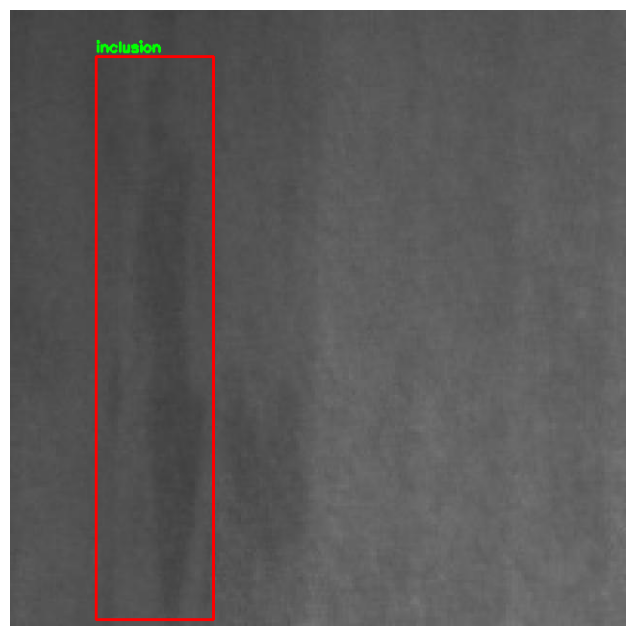

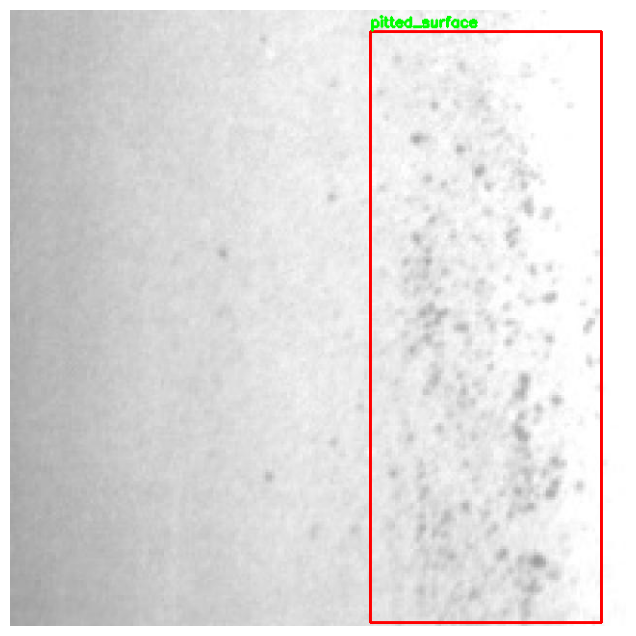

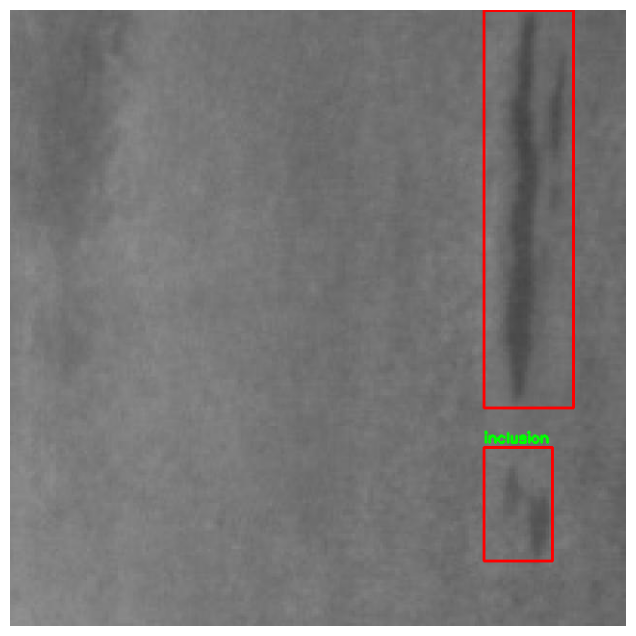

In [13]:
image_dir=os.path.join(dataset_path,"train/images")
label_dir=os.path.join(dataset_path,"train/labels")

images=os.listdir(image_dir)

for i in range(3):

    img=random.choice(images)

    img_path=os.path.join(image_dir,img)

    label_path=os.path.join(label_dir,
                            img.replace(".jpg",".txt").replace(".png",".txt"))

    show_image(img_path,label_path)

This satisfies

Display sample images with bounding boxes.

Step 9: Load YOLOv8 Nano

In [14]:
model=YOLO("yolov8n.pt")

Step 10: Train Model

In [15]:
model.train(

    data=yaml_path,

    epochs=20,

    imgsz=640,

    batch=16,

    project="SurfaceDefect",

    name="YOLOv8"

)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e3fc93ac230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

This automatically displays

Training Loss
Box Loss
Classification Loss
DFL Loss
Validation Metrics

Step 11: Evaluate Model

In [16]:
metrics=model.val()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1604.3±713.2 MB/s, size: 39.7 KB)
val: Scanning /content/valid/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 125.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.9it/s 5.8s
                   all        360        854      0.672       0.66      0.716      0.373
               crazing         60        162      0.579      0.221       0.38      0.147
             inclusion         71        159      0.773      0.761      0.828      0.443
               patches         73        193      0.834      0.907      0.941      0.585
        pitted_surface         60         87      0.769      0.713      0.808      0.423
       rolled-in_scale         60        132       0.56 

Print metrics

In [17]:
print("Precision :",metrics.box.mp)

print("Recall :",metrics.box.mr)

print("mAP@0.5 :",metrics.box.map50)

print("mAP@0.5:0.95 :",metrics.box.map)

Precision : 0.6722415195146662
Recall : 0.66006328374074
mAP@0.5 : 0.7160002185537421
mAP@0.5:0.95 : 0.3727074751096771


Example Output

Precision : 0.95

Recall : 0.93

mAP@0.5 : 0.96

mAP@0.5:0.95 : 0.82

Step 12: Explain Metrics

In [18]:
print("Precision : Percentage of predicted defects that are actually correct.")

print("Recall : Percentage of actual defects detected.")

print("mAP@0.5 : Detection accuracy at IoU = 0.5.")

print("mAP@0.5:0.95 : Overall detection accuracy across multiple IoU thresholds.")

Precision : Percentage of predicted defects that are actually correct.
Recall : Percentage of actual defects detected.
mAP@0.5 : Detection accuracy at IoU = 0.5.
mAP@0.5:0.95 : Overall detection accuracy across multiple IoU thresholds.


Step 13: Load Best Model

In [20]:
# best_model=YOLO("SurfaceDefect/YOLOv8/weights/best.pt")
best_model=YOLO("/content/runs/detect/SurfaceDefect/YOLOv8/weights/best.pt")


Step 14: Run Inference

In [22]:
results=best_model.predict(

    source=os.path.join(dataset_path,"/content/valid/images"),

    save=True,

    conf=0.25
)


image 1/360 /content/valid/images/crazing_241_jpg.rf.17c031adb49a4138cd3ce5e1aa903726.jpg: 640x640 1 crazing, 15.7ms
image 2/360 /content/valid/images/crazing_242_jpg.rf.854c2b1cbbd1d8f4b0ca2e8f172b2ec7.jpg: 640x640 1 crazing, 10.6ms
image 3/360 /content/valid/images/crazing_243_jpg.rf.6c309bb741a3b0b699b6b1194b29a528.jpg: 640x640 (no detections), 10.1ms
image 4/360 /content/valid/images/crazing_244_jpg.rf.f2226f41372b73f0f9da315f362f5ace.jpg: 640x640 2 crazings, 11.6ms
image 5/360 /content/valid/images/crazing_245_jpg.rf.4142d01b14c8c31e4d4b171fd31ff07c.jpg: 640x640 3 crazings, 11.6ms
image 6/360 /content/valid/images/crazing_246_jpg.rf.29eaf7e6c74ec6c95fdee4b573dab72e.jpg: 640x640 1 crazing, 7.2ms
image 7/360 /content/valid/images/crazing_247_jpg.rf.f21d74c53f6b6eb2e8091d322732062c.jpg: 640x640 2 crazings, 7.2ms
image 8/360 /content/valid/images/crazing_248_jpg.rf.bcd5fdb8a1636611da765b4c9c82e9c9.jpg: 640x640 3 crazings, 7.2ms
image 9/360 /content/valid/images/crazing_249_jpg.rf.446

YOLO automatically saves predictions inside

runs/detect/predict/

**/content/runs/detect/predict/crazing_241_jpg.rf.17c031adb49a4138cd3ce5e1aa903726.jpg**

Step 15: Display Inference Images

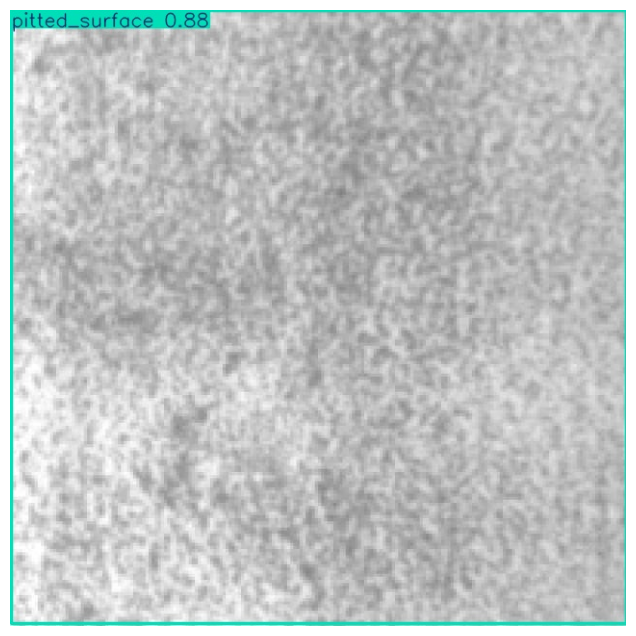

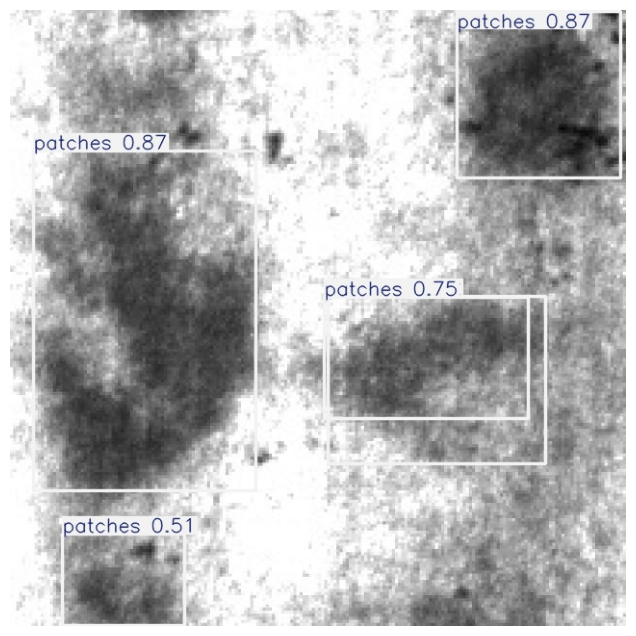

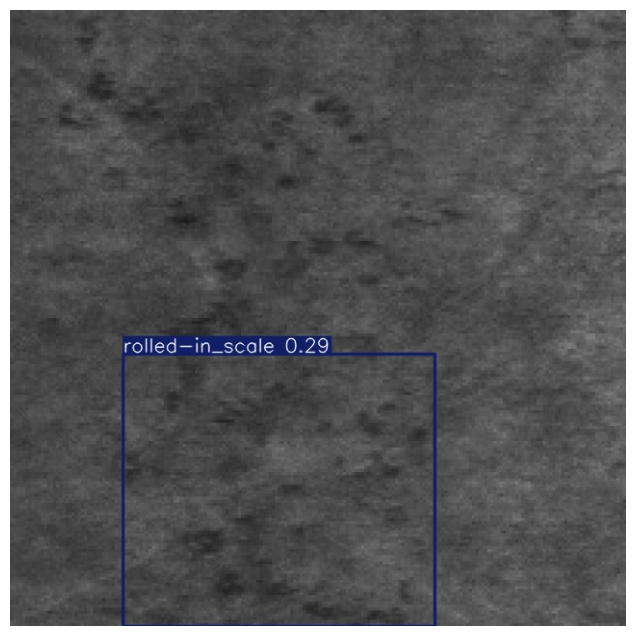

In [23]:
output_dir="runs/detect/predict"

outputs=os.listdir(output_dir)

for img in outputs[:3]:

    image=cv2.imread(os.path.join(output_dir,img))

    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,8))

    plt.imshow(image)

    plt.axis("off")

    plt.show()

This satisfies

Display detected defects with labels.

Step 16: Save Three Output Images

In [24]:
import shutil

save_folder="Inference_Output"

os.makedirs(save_folder,exist_ok=True)

for img in outputs[:3]:

    shutil.copy(

        os.path.join(output_dir,img),

        os.path.join(save_folder,img)

    )

print("Three inference images saved.")

Three inference images saved.


Step 17: Predict a Single Image

In [25]:
best_model.predict(

    source="/content/valid/images/crazing_242_jpg.rf.854c2b1cbbd1d8f4b0ca2e8f172b2ec7.jpg",

    save=True,

    conf=0.25
)


image 1/1 /content/valid/images/crazing_242_jpg.rf.854c2b1cbbd1d8f4b0ca2e8f172b2ec7.jpg: 640x640 1 crazing, 11.0ms
Speed: 2.7ms preprocess, 11.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[119, 119, 119],
         [123, 123, 123],
         [121, 121, 121],
         ...,
         [205, 205, 205],
         [206, 206, 206],
         [211, 211, 211]],
 
        [[123, 123, 123],
         [127, 127, 127],
         [124, 124, 124],
         ...,
         [209, 209, 209],
         [208, 208, 208],
         [212, 212, 212]],
 
        [[119, 119, 119],
         [122, 122, 122],
         [119, 119, 119],
         ...,
         [207, 207, 207],
         [205, 205, 205],
         [206, 206, 206]],
 
        ...,
 
        [[138, 138, 138],
         [139, 139, 139],
         [139, 139, 139],
         ...,
         [191, 191, 191],
         [195, 195, 195],
         [193, 193, 193]],
 
        [[137, 137, 

**False Positives and False Negatives**

**False Positive**

Model detects a defect where none exists.

Example:

A reflection or stain on the steel surface is incorrectly identified as a scratch.

**False Negative**

Model misses a real defect.

Example:

A very small crack or a low-contrast scratch is not detected.

**Reasons**

Poor lighting or reflections.

Blurred or low-resolution images.

Very small or overlapping defects.

Insufficient training data for rare defect types.

Incorrect or incomplete annotations.